In [2]:
import pickle
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# --------------------------------------------------
# Load dataset
# --------------------------------------------------
def loadDataSet():
    fnSave = 'project2.dat'
    print(f'Loading data from {fnSave}')
    with open(fnSave, 'rb') as f:
        res = pickle.load(f)

    X_train = res['X_train']
    L_train = res['L_train'].astype(int)
    X_test = res['X_test']
    L_test = res['L_test'].astype(int)
    numCat = res['numCat']
    return X_train, L_train, X_test, L_test, numCat

In [3]:
# --------------------------------------------------
# Build deep neural network
# --------------------------------------------------
class DeepMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=8, num_hidden_layers=5, num_classes=10):
        super().__init__()

        layers = []

        # First hidden layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())

        # Remaining hidden layers
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())

        # Output layer
        layers.append(nn.Linear(hidden_dim, num_classes))

        # Combine all layers into a sequential model that can be called in the forward pass
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [4]:
# --------------------------------------------------
# Training function
# --------------------------------------------------
def train_model(model, train_loader, lr=1e-3, epochs=500, device='cpu'):
    criterion = nn.CrossEntropyLoss()

    # Use the Adam optimizer as the algorithm for updating the model parameters during backpropagation 
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.to(device)
    loss_history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        total_samples = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            # feed the input through the model to get the predicted logits and compute the loss
            logits = model(xb)
            loss = criterion(logits, yb)

            # compute the gradients of the loss with respect to the model parameters and update the parameters
            loss.backward()
            optimizer.step()

            # accumulate the average loss for this batch 
            batch_size = xb.shape[0]
            running_loss += loss.item() * batch_size
            total_samples += batch_size

        epoch_loss = running_loss / total_samples
        loss_history.append(epoch_loss)

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:4d} | loss = {epoch_loss:.6f}")

    return loss_history

In [5]:
# --------------------------------------------------
# Evaluation function
# --------------------------------------------------
def evaluate_model(model, X, y, device='cpu'):
    model.eval()
    model.to(device)

    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(X_tensor)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

    acc = np.mean(preds == y)
    return acc, preds


# --------------------------------------------------
# Plot training curve
# --------------------------------------------------
def plot_loss_curve(loss_history, title='Training Loss'):
    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel('Epoch')
    plt.ylabel('Cross-entropy loss')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --------------------------------------------------
# Plot confusion matrix
# --------------------------------------------------
def plot_confusion_matrix(y_true, y_pred, num_classes, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(num_classes))
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [6]:

# --------------------------------------------------
# One experiment run
# --------------------------------------------------
def run_single_experiment(N=8, L=5, lr=1e-3, epochs=500, batch_size=64, device='cpu'):
    X_train, y_train, X_test, y_test, num_classes = loadDataSet()

    # Convert labels to 0-9 from 1-10
    y_train = y_train - 1
    y_test = y_test - 1

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Fresh random seed based on time
    seed = int(time.time() * 1000) % (2**32)
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = DeepMLP(
        input_dim=2,
        hidden_dim=N,
        num_hidden_layers=L,
        num_classes=num_classes
    )

    loss_history = train_model(model, train_loader, lr=lr, epochs=epochs, device=device)

    train_acc, train_pred = evaluate_model(model, X_train, y_train, device=device)
    test_acc, test_pred = evaluate_model(model, X_test, y_test, device=device)

    print(f"\nFinal results for N={N}, L={L}, lr={lr}")
    print(f"Train accuracy = {train_acc:.4f}")
    print(f"Test accuracy  = {test_acc:.4f}")

    return {
        'model': model,
        'loss_history': loss_history,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'y_test': y_test,
        'test_pred': test_pred,
        'num_classes': num_classes
    }

In [7]:
# --------------------------------------------------
# Part (a): N=8, L=5 with learning-rate experiments
# --------------------------------------------------
def part_a_learning_rate_search():
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    learning_rates = [1e-2, 3e-3, 1e-3, 3e-4]
    results = []

    for lr in learning_rates:
        print("\n" + "="*60)
        print(f"Running experiment for lr = {lr}")
        res = run_single_experiment(N=8, L=5, lr=lr, epochs=500, batch_size=64, device=device)
        results.append((lr, res))

    # Plot all loss curves together
    plt.figure(figsize=(7, 5))
    for lr, res in results:
        plt.plot(res['loss_history'], label=f"lr={lr}")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.title("Training curves for N=8, L=5")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Pick best by test accuracy
    best_lr, best_res = max(results, key=lambda x: x[1]['test_acc'])
    print(f"\nBest learning rate based on test accuracy: {best_lr}")
    print(f"Best test accuracy: {best_res['test_acc']:.4f}")

    plot_confusion_matrix(
        best_res['y_test'],
        best_res['test_pred'],
        best_res['num_classes'],
        title=f"Confusion Matrix (N=8, L=5, lr={best_lr})"
    )

    return results


# --------------------------------------------------
# Part (b): sweep over N and L
# --------------------------------------------------
def part_b_grid_search():
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    Ns = [15, 10, 7, 5]
    Ls = [2, 5, 10]

    # You can adjust lr if needed after part (a)
    lr = 1e-3
    epochs = 500

    summary = []

    for N in Ns:
        for L in Ls:
            print("\n" + "="*60)
            print(f"Running N={N}, L={L}")
            res = run_single_experiment(N=N, L=L, lr=lr, epochs=epochs, batch_size=64, device=device)
            summary.append({
                'N': N,
                'L': L,
                'train_acc': res['train_acc'],
                'test_acc': res['test_acc'],
                'final_loss': res['loss_history'][-1]
            })

    # Print summary
    print("\nSummary table:")
    print(f"{'N':>5} {'L':>5} {'Train Acc':>12} {'Test Acc':>12} {'Final Loss':>12}")
    for row in summary:
        print(f"{row['N']:5d} {row['L']:5d} {row['train_acc']:12.4f} {row['test_acc']:12.4f} {row['final_loss']:12.6f}")

    # Heatmap-like plot using text
    plt.figure(figsize=(6, 4))
    for row in summary:
        plt.scatter(row['L'], row['N'], s=200)
        plt.text(row['L'], row['N'], f"{row['test_acc']:.2f}", ha='center', va='center', color='white')
    plt.xticks(Ls)
    plt.yticks(Ns)
    plt.xlabel("Number of hidden layers L")
    plt.ylabel("Hidden width N")
    plt.title("Test accuracy for different N and L")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return summary



Running experiment for lr = 0.01
Loading data from project2.dat
Epoch   50 | loss = 0.166661
Epoch  100 | loss = 0.135860
Epoch  150 | loss = 0.181275
Epoch  200 | loss = 0.136093
Epoch  250 | loss = 0.141924
Epoch  300 | loss = 0.108849
Epoch  350 | loss = 0.174581
Epoch  400 | loss = 0.117470
Epoch  450 | loss = 0.181602
Epoch  500 | loss = 0.072914

Final results for N=8, L=5, lr=0.01
Train accuracy = 0.9637
Test accuracy  = 0.9597

Running experiment for lr = 0.003
Loading data from project2.dat
Epoch   50 | loss = 0.210467
Epoch  100 | loss = 0.166286
Epoch  150 | loss = 0.153803
Epoch  200 | loss = 0.130423
Epoch  250 | loss = 0.116084
Epoch  300 | loss = 0.117867
Epoch  350 | loss = 0.102244
Epoch  400 | loss = 0.109619
Epoch  450 | loss = 0.141849
Epoch  500 | loss = 0.085334

Final results for N=8, L=5, lr=0.003
Train accuracy = 0.9732
Test accuracy  = 0.9623

Running experiment for lr = 0.001
Loading data from project2.dat
Epoch   50 | loss = 0.261628
Epoch  100 | loss = 0.1

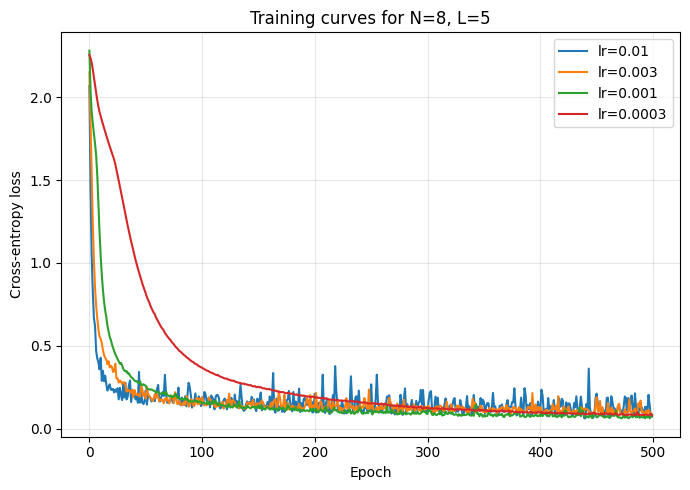


Best learning rate based on test accuracy: 0.0003
Best test accuracy: 0.9718


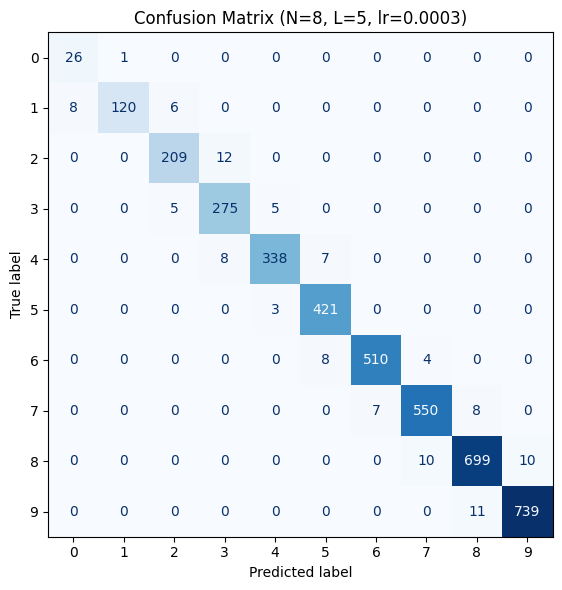


Running N=15, L=2
Loading data from project2.dat
Epoch   50 | loss = 0.557043
Epoch  100 | loss = 0.260403
Epoch  150 | loss = 0.166079
Epoch  200 | loss = 0.130064
Epoch  250 | loss = 0.102089
Epoch  300 | loss = 0.084029
Epoch  350 | loss = 0.081109
Epoch  400 | loss = 0.062368
Epoch  450 | loss = 0.056950
Epoch  500 | loss = 0.049257

Final results for N=15, L=2, lr=0.001
Train accuracy = 0.9915
Test accuracy  = 0.9805

Running N=15, L=5
Loading data from project2.dat
Epoch   50 | loss = 0.162485
Epoch  100 | loss = 0.096613
Epoch  150 | loss = 0.081509
Epoch  200 | loss = 0.057138
Epoch  250 | loss = 0.045379
Epoch  300 | loss = 0.040794
Epoch  350 | loss = 0.029961
Epoch  400 | loss = 0.034238
Epoch  450 | loss = 0.060719
Epoch  500 | loss = 0.026333

Final results for N=15, L=5, lr=0.001
Train accuracy = 0.9978
Test accuracy  = 0.9868

Running N=15, L=10
Loading data from project2.dat
Epoch   50 | loss = 0.192414
Epoch  100 | loss = 0.112839
Epoch  150 | loss = 0.089674
Epoch  2

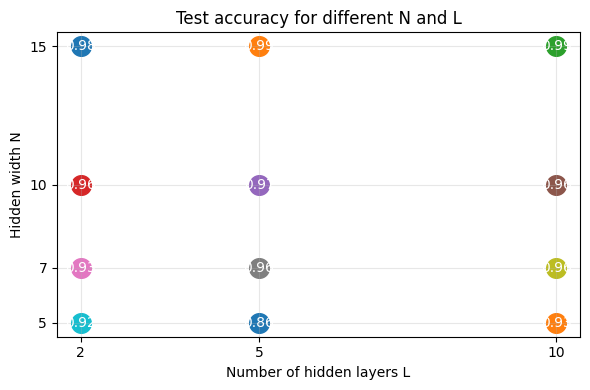

In [8]:
# --------------------------------------------------
# Main
# --------------------------------------------------
if __name__ == "__main__":
    # Part (a)
    results_a = part_a_learning_rate_search()

    # Part (b)
    summary_b = part_b_grid_search()